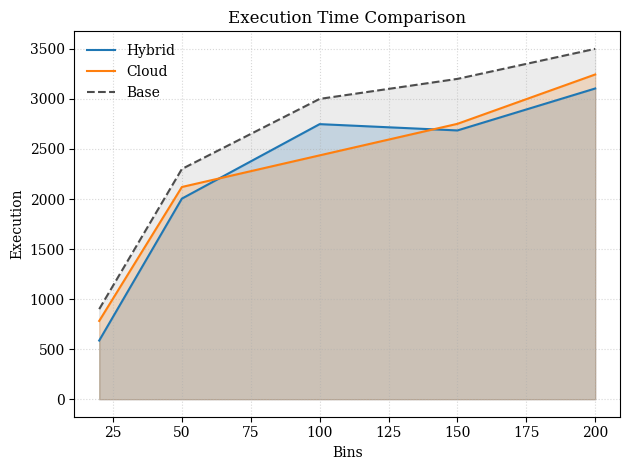

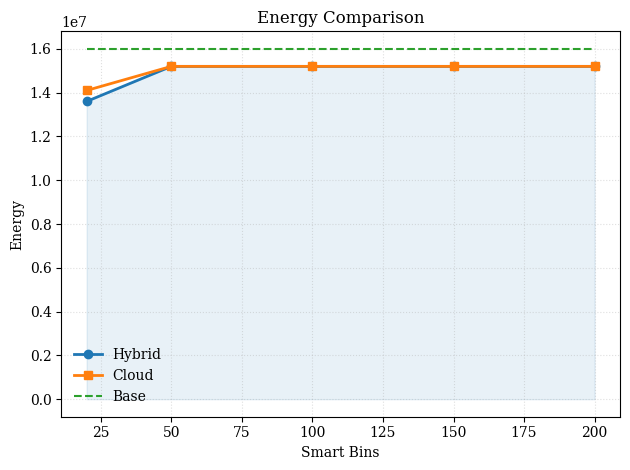

<Figure size 640x480 with 0 Axes>

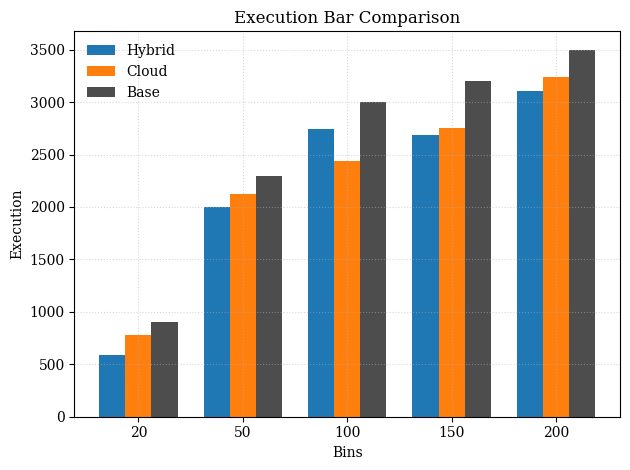

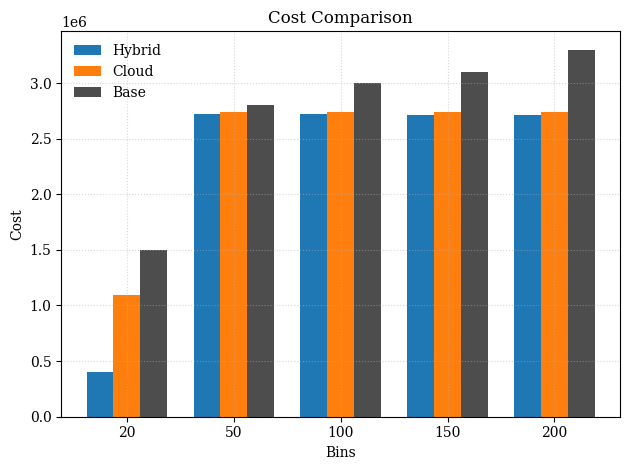

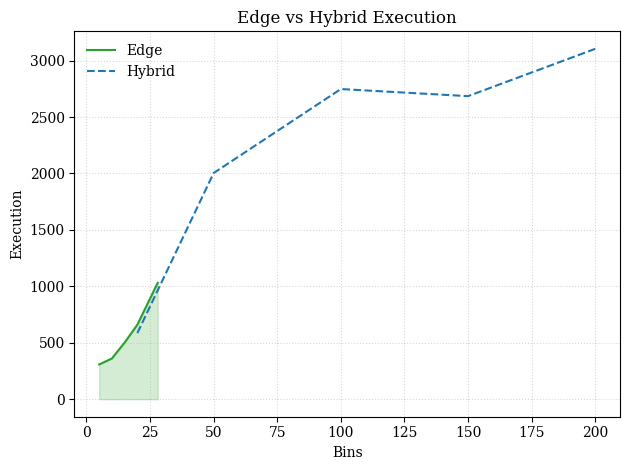

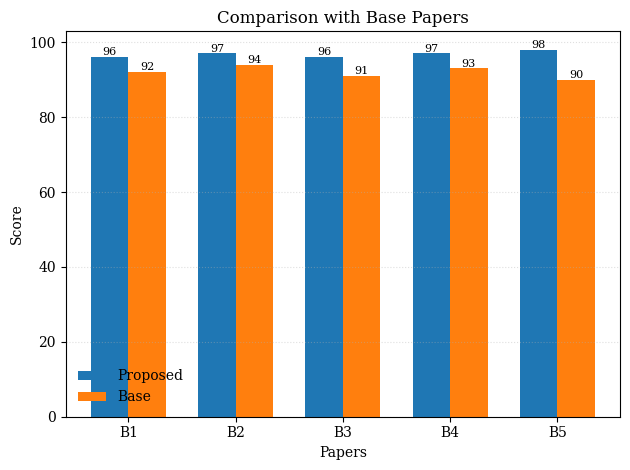

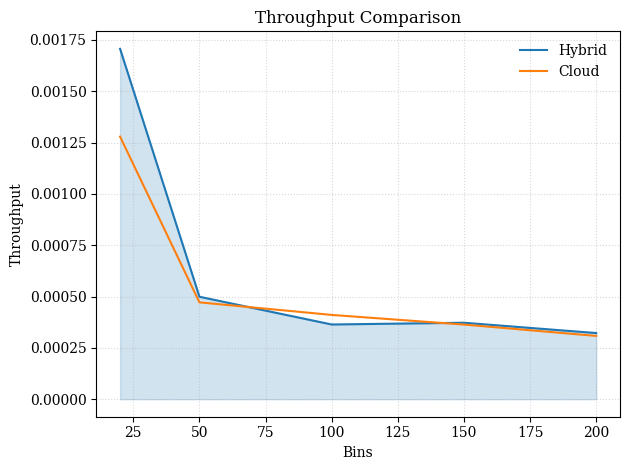

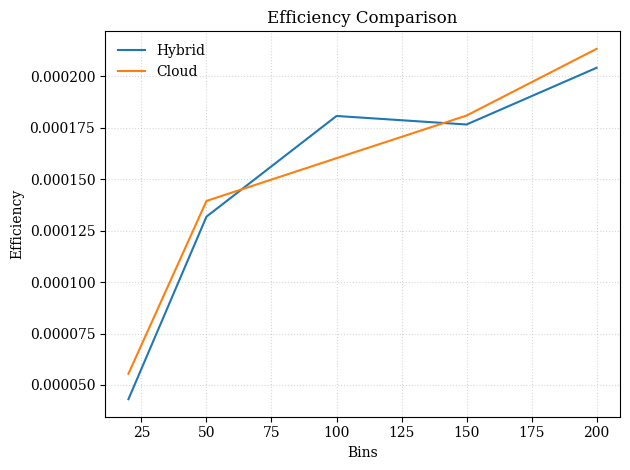

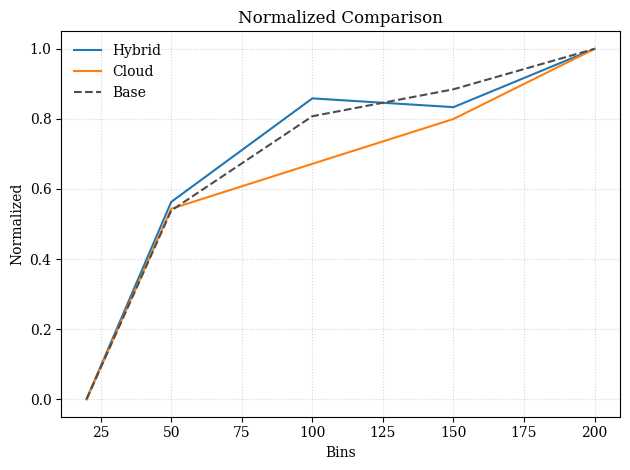

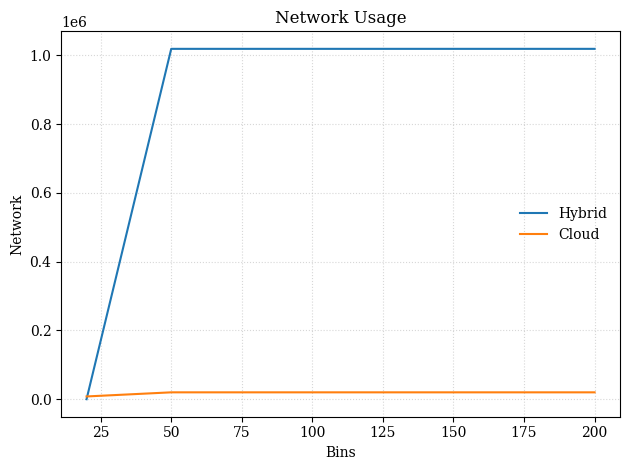

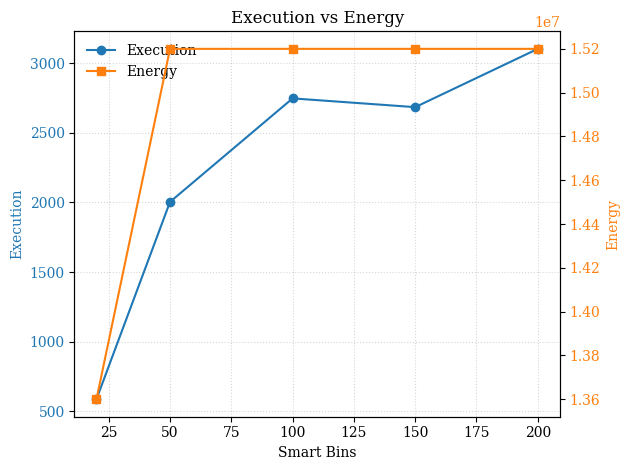

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os, zipfile
from google.colab import files

%matplotlib inline

# ===== STYLE FIX =====
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 10
})

# ===== COLORS =====
c_hybrid = "#1f77b4"
c_cloud  = "#ff7f0e"
c_edge   = "#2ca02c"
c_base   = "#4d4d4d"

# ===== DATA =====
bins = np.array([20,50,100,150,200])
x = np.arange(len(bins))
w = 0.25

hybrid_exec = np.array([586,2004,2748,2685,3104])
cloud_exec  = np.array([782,2120,2436,2751,3244])
base_exec   = np.array([900,2300,3000,3200,3500])

hybrid_energy = np.array([1.36e7,1.52e7,1.52e7,1.52e7,1.52e7])
cloud_energy  = np.array([1.41e7,1.52e7,1.52e7,1.52e7,1.52e7])
base_energy   = np.array([1.6e7]*5)

cost_hybrid = np.array([400000,2719212,2719212,2716944,2716944])
cost_cloud  = np.array([1095695,2737175,2740655,2740655,2740655])
base_cost   = np.array([1500000,2800000,3000000,3100000,3300000])

hybrid_network = np.array([0,1018658,1018658,1018658,1018658])
cloud_network  = np.array([7992,19978,19978,19978,19978])

edge_bins = np.array([5,10,15,20,28])
edge_exec = np.array([308,361,502,660,1031])
edge_energy = np.array([8.79e5,9.22e5,9.65e5,1.01e6,1.07e6])

# ===== FUNCTIONS =====
def style(title,x,y):
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(frameon=False)
    plt.tight_layout()

def save(name):
    plt.savefig(name, dpi=300)
    plt.show()
    plt.close()

# ================= 1 FILLED EXECUTION =================
plt.figure()
plt.plot(bins, hybrid_exec, color=c_hybrid, label="Hybrid")
plt.fill_between(bins, hybrid_exec, alpha=0.2, color=c_hybrid)

plt.plot(bins, cloud_exec, color=c_cloud, label="Cloud")
plt.fill_between(bins, cloud_exec, alpha=0.2, color=c_cloud)

plt.plot(bins, base_exec, '--', color=c_base, label="Base")
plt.fill_between(bins, base_exec, alpha=0.1, color=c_base)

style("Execution Time Comparison","Bins","Execution")
save("g1_exec.png")

# ===== 2 FIXED ENERGY GRAPH =====
plt.figure()

plt.plot(bins, hybrid_energy, 'o-', label='Hybrid', color="#1f77b4", linewidth=2)
plt.plot(bins, cloud_energy,  's-', label='Cloud',  color="#ff7f0e", linewidth=2)

# subtle fill (ONLY for hybrid)
plt.fill_between(bins, hybrid_energy, alpha=0.1, color="#1f77b4")

# base as reference line
plt.plot(bins, base_energy, '--', label='Base', color="#2ca02c")

plt.xlabel("Smart Bins")
plt.ylabel("Energy")
plt.title("Energy Comparison")

plt.legend(loc='lower left', frameon=False)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()
save("g2_energy.png")

# ================= 3 GROUPED EXEC BAR =================
plt.figure()
plt.bar(x-w, hybrid_exec, w, label='Hybrid', color=c_hybrid)
plt.bar(x, cloud_exec, w, label='Cloud', color=c_cloud)
plt.bar(x+w, base_exec, w, label='Base', color=c_base)

plt.xticks(x, bins)
style("Execution Bar Comparison","Bins","Execution")
save("g3_exec_bar.png")
# ================= 4 COST =================
plt.figure()
plt.bar(x-w, cost_hybrid, w, label='Hybrid', color=c_hybrid)
plt.bar(x, cost_cloud, w, label='Cloud', color=c_cloud)
plt.bar(x+w, base_cost, w, label='Base', color=c_base)

plt.xticks(x, bins)
style("Cost Comparison","Bins","Cost")
save("g4_cost.png")

# ================= 5 EDGE VS HYBRID =================
plt.figure()
plt.plot(edge_bins, edge_exec, color=c_edge, label="Edge")
plt.fill_between(edge_bins, edge_exec, alpha=0.2, color=c_edge)

plt.plot(bins, hybrid_exec, '--', color=c_hybrid, label="Hybrid")

style("Edge vs Hybrid Execution","Bins","Execution")
save("g5_edge.png")

# ================= 6 BASE PAPER BAR =================

papers = ['B1','B2','B3','B4','B5']
x = np.arange(len(papers))
w = 0.35  # wider bars = tighter grouping

proposed = [96,97,96,97,98]
base     = [92,94,91,93,90]

plt.figure()

plt.bar(x - w/2, proposed, w, label='Proposed', color="#1f77b4")
plt.bar(x + w/2, base,     w, label='Base',     color="#ff7f0e")

plt.xticks(x, papers)
plt.ylabel("Score")
plt.xlabel("Papers")
plt.title("Comparison with Base Papers")

# VALUE LABELS (important for paper look)
for i, v in enumerate(proposed):
    plt.text(i - w/2, v + 0.5, str(v), ha='center', fontsize=8)

for i, v in enumerate(base):
    plt.text(i + w/2, v + 0.5, str(v), ha='center', fontsize=8)

plt.legend(frameon=False)
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# ================= 7 THROUGHPUT =================
plt.figure()
plt.plot(bins, 1/hybrid_exec, color=c_hybrid, label="Hybrid")
plt.fill_between(bins, 1/hybrid_exec, alpha=0.2, color=c_hybrid)

plt.plot(bins, 1/cloud_exec, color=c_cloud, label="Cloud")

style("Throughput Comparison","Bins","Throughput")
save("g7_throughput.png")

# ================= 8 EFFICIENCY =================
plt.figure()
plt.plot(bins, hybrid_exec/hybrid_energy, color=c_hybrid, label="Hybrid")
plt.plot(bins, cloud_exec/cloud_energy, color=c_cloud, label="Cloud")

style("Efficiency Comparison","Bins","Efficiency")
save("g8_efficiency.png")

# ================= 9 NORMALIZED =================
def norm(a): return (a-min(a))/(max(a)-min(a)+1e-9)

plt.figure()
plt.plot(bins, norm(hybrid_exec), color=c_hybrid, label="Hybrid")
plt.plot(bins, norm(cloud_exec), color=c_cloud, label="Cloud")
plt.plot(bins, norm(base_exec), '--', color=c_base, label="Base")

style("Normalized Comparison","Bins","Normalized")
save("g9_norm.png")

# ================= 10 NETWORK =================
plt.figure()
plt.plot(bins, hybrid_network, color=c_hybrid, label="Hybrid")
plt.plot(bins, cloud_network, color=c_cloud, label="Cloud")
plt.legend(loc='lower right', frameon=False)
style("Network Usage","Bins","Network")
save("g10_network.png")

# ================= 11 DUAL AXIS =================
fig, ax1 = plt.subplots()

# ---- LEFT AXIS (Execution) ----
line1, = ax1.plot(bins, hybrid_exec, color=c_hybrid, marker='o', label="Execution")
ax1.set_xlabel("Smart Bins")
ax1.set_ylabel("Execution", color=c_hybrid)
ax1.tick_params(axis='y', labelcolor=c_hybrid)

# ---- RIGHT AXIS (Energy) ----
ax2 = ax1.twinx()
line2, = ax2.plot(bins, hybrid_energy, color=c_cloud, marker='s', label="Energy")
ax2.set_ylabel("Energy", color=c_cloud)
ax2.tick_params(axis='y', labelcolor=c_cloud)

# ---- COMBINED LEGEND (IMPORTANT FIX) ----
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=False)

# ---- STYLE ----
plt.title("Execution vs Energy")
ax1.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
save("g11_dual.png")




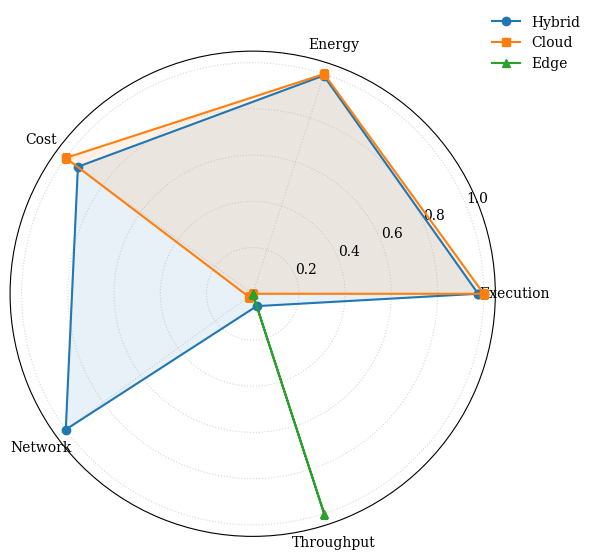

In [ ]:
# ===== RADAR WITH 5 PARAMETERS =====

labels = ['Execution','Energy','Cost','Network','Throughput']

# ===== VALUES =====
h_vals = [
    np.mean(hybrid_exec),
    np.mean(hybrid_energy),
    np.mean(cost_hybrid),
    np.mean(hybrid_network),
    np.mean(1/hybrid_exec)
]

c_vals = [
    np.mean(cloud_exec),
    np.mean(cloud_energy),
    np.mean(cost_cloud),
    np.mean(cloud_network),
    np.mean(1/cloud_exec)
]

e_vals = [
    np.mean(edge_exec),
    np.mean(edge_energy),
    0,
    0,
    np.mean(1/edge_exec)
]

# ===== NORMALIZATION =====
data = np.array([h_vals, c_vals, e_vals])
norm = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0) + 1e-9)

h, c, e = norm[0], norm[1], norm[2]

# ===== CLOSE LOOP =====
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.append(angles, angles[0])

h = np.append(h, h[0])
c = np.append(c, c[0])
e = np.append(e, e[0])

# ===== PLOT =====
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, h, 'o-', label='Hybrid', color=c_hybrid)
ax.plot(angles, c, 's-', label='Cloud', color=c_cloud)
ax.plot(angles, e, '^-', label='Edge', color=c_edge)

ax.fill(angles, h, alpha=0.1, color=c_hybrid)
ax.fill(angles, c, alpha=0.1, color=c_cloud)
ax.fill(angles, e, alpha=0.1, color=c_edge)

ax.set_thetagrids(angles[:-1]*180/np.pi, labels)

ax.grid(linestyle=':', alpha=0.5)

plt.legend(loc='upper right', bbox_to_anchor=(1.2,1.1), frameon=False)

plt.tight_layout()
plt.savefig("g13_radar.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ===== DOWNLOAD =====
with zipfile.ZipFile('FINAL_PERFECT_GRAPHS.zip','w') as z:
    for f in os.listdir():
        if f.endswith(".png"):
            z.write(f)

files.download('FINAL_PERFECT_GRAPHS.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>